# Student Performance Prediction Using Machine Learning and Deep Learning

## Project Overview

This project aims to predict student academic performance using machine learning and deep learning techniques.

The dataset used in this project is the Student Performance Dataset, which contains information about students' demographic, social, and academic characteristics.

The goal is to classify students into two categories:

- Pass
- Fail

based on their academic and personal information.

## Dataset

The dataset contains student information such as:

- Age
- Gender
- Study time
- Absences
- Family background
- Previous academic performance
- Social factors

The final grade (G3) was transformed into a binary target variable:

Pass:
G3 >= 10

Fail:
G3 < 10

## Project Pipeline

The project follows these steps:

1. Load the dataset
2. Explore and understand the data
3. Clean and preprocess data
4. Perform feature engineering
5. Train machine learning models
6. Train deep learning models
7. Evaluate model performance
8. Compare results

## Machine Learning Models

Traditional machine learning models implemented:

- Logistic Regression
- Decision Tree
- Random Forest

## Deep Learning Models

Deep learning approaches implemented using TensorFlow:

- Sequential Neural Network
- Dropout Neural Network
- Functional API Neural Network
- tf.data Pipeline

## Evaluation Metrics

The models are evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- ROC Curve
- AUC Score


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [19]:
import pandas as pd

df = pd.read_csv("student-mat.csv", sep=";")

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [20]:
# Number of rows and columns
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

Dataset Shape: (395, 33)

Columns:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [21]:
print("Dataset Shape:", df.shape)
df.info()

Dataset Shape: (395, 33)
<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 no

In [22]:
# Summary statistics for numerical columns
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [23]:
# Check the target variable (Final Grade)
df["G3"].describe()

count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64

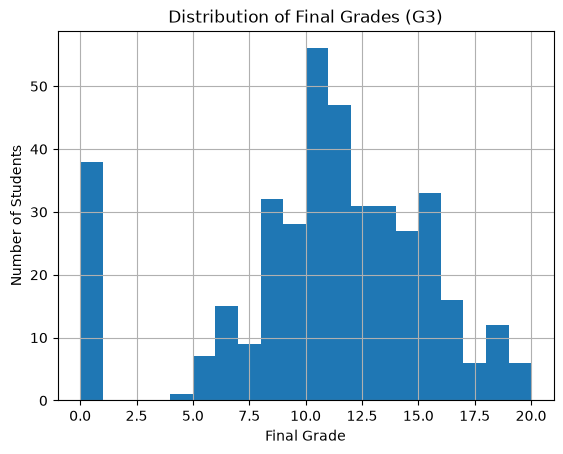

In [24]:
# Check class distribution of G3
import matplotlib.pyplot as plt

df["G3"].hist(bins=20)

plt.title("Distribution of Final Grades (G3)")
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")
plt.show()

In [25]:
# Create target variable

df["Pass"] = (df["G3"] >= 10).astype(int)

df[["G3", "Pass"]].head()

,G3,Pass
0,6,0
1,6,0
2,10,1
3,15,1
4,10,1


In [26]:
# Check class distribution

print(df["Pass"].value_counts())

Pass
1    265
0    130
Name: count, dtype: int64


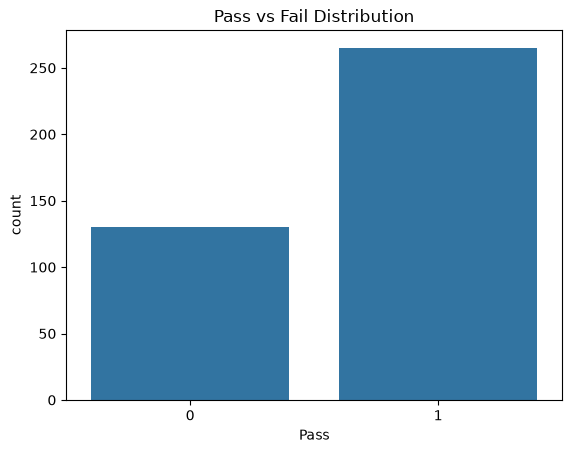

In [27]:
# Visualize Pass/Fail distribution

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="Pass")

plt.title("Pass vs Fail Distribution")
plt.show()

In [28]:
# Create features and target

X = df.drop(["Pass", "G3"], axis=1)

y = df["Pass"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (395, 32)
y shape: (395,)


In [29]:
# Check data types

print(X.dtypes)

school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
dtype: object


In [30]:
# Convert categorical columns

X = pd.get_dummies(X, drop_first=True)

print("New shape:", X.shape)

New shape: (395, 41)


In [31]:
X.head()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,3,4,3,2,2,...,True,False,True,False,True,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,True,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,True,False,True,True,False,False


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (316, 41)
Test set: (79, 41)


In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed!")

Scaling completed!


In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Create model
lr_model = LogisticRegression(max_iter=1000)

# Train model
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = lr_model.predict(X_test_scaled)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:", accuracy)

Logistic Regression Accuracy: 0.8481012658227848


In [35]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.88      0.79        26
           1       0.94      0.83      0.88        53

    accuracy                           0.85        79
   macro avg       0.83      0.86      0.84        79
weighted avg       0.86      0.85      0.85        79



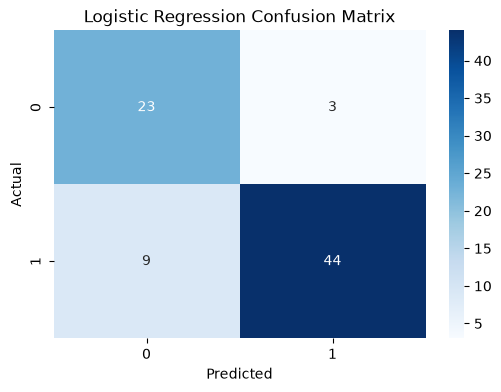

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

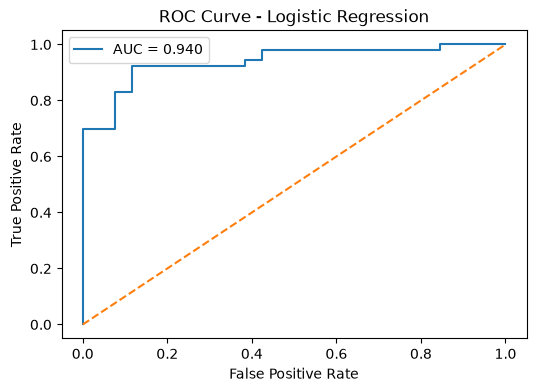

AUC Score: 0.939767779390421


In [37]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

print("AUC Score:", auc_score)

In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create model
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

# Train
dt_model.fit(X_train, y_train)

# Predict
dt_pred = dt_model.predict(X_test)

# Accuracy
dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.8607594936708861

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.96      0.82        26
           1       0.98      0.81      0.89        53

    accuracy                           0.86        79
   macro avg       0.85      0.89      0.85        79
weighted avg       0.89      0.86      0.86        79



In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train
rf_model.fit(X_train, y_train)

# Predict
rf_pred = rf_model.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.8734177215189873

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.92      0.83        26
           1       0.96      0.85      0.90        53

    accuracy                           0.87        79
   macro avg       0.85      0.89      0.86        79
weighted avg       0.89      0.87      0.88        79



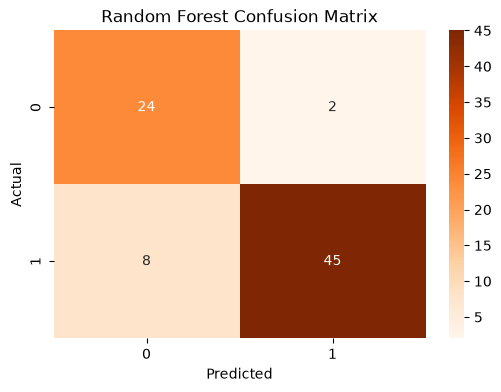

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [41]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [42]:
import pandas as pd

# Load data
df = pd.read_csv("student-mat.csv", sep=";")

# Create target
df["Pass"] = (df["G3"] >= 10).astype(int)

# Features and target
X = df.drop(["Pass", "G3"], axis=1)
y = df["Pass"]

# One-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Train/Test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data prepared successfully!")
print("X_train shape:", X_train.shape)

Data prepared successfully!
X_train shape: (316, 41)


In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

nn_model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

nn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

nn_model.summary()

c:\Users\morsa\Downloads\Student_Performance_Project\ml_env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,889 (7.38 KB)

 Trainable params: 1,889 (7.38 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
history = nn_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.6667 - loss: 0.6209 - val_accuracy: 0.7031 - val_loss: 0.5770
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7222 - loss: 0.5579 - val_accuracy: 0.7969 - val_loss: 0.5385
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7659 - loss: 0.5086 - val_accuracy: 0.7656 - val_loss: 0.5092
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7937 - loss: 0.4636 - val_accuracy: 0.8125 - val_loss: 0.4790
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8452 - loss: 0.4202 - val_accuracy: 0.8125 - val_loss: 0.4491
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8532 - loss: 0.3797 - val_accuracy: 0.8125 - val_loss: 0.4236
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8889 - loss: 0.3429 - val_accuracy: 0.8125 - val_loss: 0.3984
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9008 - loss: 0.3083 - val_accuracy: 0.8125 - v

In [45]:
loss, nn_accuracy = nn_model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Neural Network Accuracy:", nn_accuracy)

Neural Network Accuracy: 0.797468364238739


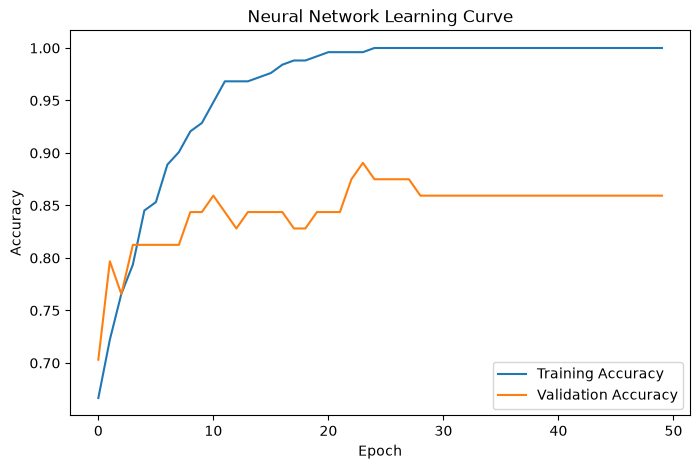

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Neural Network Learning Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [47]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

dropout_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

dropout_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

dropout_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 64)             │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,801 (18.75 KB)

 Trainable params: 4,801 (18.75 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
dropout_history = dropout_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.5040 - loss: 0.7667 - val_accuracy: 0.7031 - val_loss: 0.5859
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6508 - loss: 0.6100 - val_accuracy: 0.7656 - val_loss: 0.5149
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7103 - loss: 0.5427 - val_accuracy: 0.7812 - val_loss: 0.4774
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7778 - loss: 0.4952 - val_accuracy: 0.7812 - val_loss: 0.4428
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8135 - loss: 0.4205 - val_accuracy: 0.7969 - val_loss: 0.4047
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8413 - loss: 0.4178 - val_accuracy: 0.8281 - val_loss: 0.3776
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8413 - loss: 0.3655 - val_accuracy: 0.8438 - val_loss: 0.3533
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8452 - loss: 0.3374 - val_accuracy: 0.8750 - v

In [49]:
loss, dropout_accuracy = dropout_model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Dropout Model Accuracy:", dropout_accuracy)

Dropout Model Accuracy: 0.8481012582778931


In [50]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

inputs = Input(shape=(X_train_scaled.shape[1],))

x = Dense(64, activation='relu')(inputs)
x = Dense(32, activation='relu')(x)

outputs = Dense(1, activation='sigmoid')(x)

functional_model = Model(inputs=inputs, outputs=outputs)

functional_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

functional_model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 41)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,801 (18.75 KB)

 Trainable params: 4,801 (18.75 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
functional_history = functional_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.6508 - loss: 0.6453 - val_accuracy: 0.6719 - val_loss: 0.6311
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7659 - loss: 0.5223 - val_accuracy: 0.7344 - val_loss: 0.5477
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8413 - loss: 0.4404 - val_accuracy: 0.7500 - val_loss: 0.4869
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8889 - loss: 0.3718 - val_accuracy: 0.8125 - val_loss: 0.4376
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9246 - loss: 0.3129 - val_accuracy: 0.8281 - val_loss: 0.4030
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9524 - loss: 0.2604 - val_accuracy: 0.8281 - val_loss: 0.3793
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9603 - loss: 0.2173 - val_accuracy: 0.8438 - val_loss: 0.3588
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9722 - loss: 0.1768 - val_accuracy: 0.8594 - v

In [52]:
loss, functional_accuracy = functional_model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Functional API Accuracy:", functional_accuracy)

Functional API Accuracy: 0.8354430198669434


In [53]:
import tensorflow as tf

train_dataset = tf.data.Dataset.from_tensor_slices(
    (X_train_scaled.astype("float32"),
     y_train.astype("float32"))
)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (X_test_scaled.astype("float32"),
     y_test.astype("float32"))
)

train_dataset = train_dataset.shuffle(1000).batch(16)
test_dataset = test_dataset.batch(16)

print("tf.data pipeline created!")

tf.data pipeline created!


In [54]:
tfdata_model = tf.keras.Sequential([
    tf.keras.layers.Dense(
        32,
        activation='relu',
        input_shape=(X_train_scaled.shape[1],)
    ),
    tf.keras.layers.Dense(
        16,
        activation='relu'
    ),
    tf.keras.layers.Dense(
        1,
        activation='sigmoid'
    )
])

tfdata_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

c:\Users\morsa\Downloads\Student_Performance_Project\ml_env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [55]:
tfdata_history = tfdata_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=50,
    verbose=1
)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.3481 - loss: 0.9164 - val_accuracy: 0.4810 - val_loss: 0.8131
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4873 - loss: 0.7318 - val_accuracy: 0.5570 - val_loss: 0.6961
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6519 - loss: 0.6430 - val_accuracy: 0.6456 - val_loss: 0.6338
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7373 - loss: 0.5834 - val_accuracy: 0.6582 - val_loss: 0.5960
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7753 - loss: 0.5339 - val_accuracy: 0.6709 - val_loss: 0.5721
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8006 - loss: 0.4891 - val_accuracy: 0.6835 - val_loss: 0.5448
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8291 - loss: 0.4428 - val_accuracy: 0.6962 - val_loss: 0.5204
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8544 - loss: 0.3993 - val_accuracy: 0.7342 - val_loss

In [56]:
loss, tfdata_accuracy = tfdata_model.evaluate(
    test_dataset,
    verbose=0
)

print("tf.data Accuracy:", tfdata_accuracy)

tf.data Accuracy: 0.797468364238739


# Conclusion

This project compared traditional machine learning and deep learning approaches for predicting student academic performance.

The experiments showed that Random Forest achieved the best performance among all tested models.

Traditional machine learning models performed strongly because the dataset is structured and relatively small.

Deep learning models were successfully implemented using TensorFlow, but they did not outperform classical approaches.

The results demonstrate that proper preprocessing, feature engineering, and model selection are important for building effective prediction systems.

Future improvements could include collecting larger datasets, adding more student behavior features, and applying advanced optimization techniques.